In [ ]:
import arraylake as al
import marimo as mo
import matplotlib.pyplot as plt
import pint_xarray  # noqa: F401
import xarray as xr

from geospatial_learning.utils.climate_indices import (
    calculate_cold_snaps,
    calculate_heat_index,
    calculate_heat_waves,
    calculate_wind_chill,
)
from geospatial_learning.utils.xarray_helpers import (
    calculate_daily_max,
    calculate_daily_mean,
)

# NYC vs Chicago: Hot n Cold

**Attribution**: This notebook is inspired by Tom Nicholas' [Climate Risk Analysis Notebook](https://github.com/elliott-ruebush/risk-analysis-workshop/blob/main/era5.py) from NYC Climate Week in September 2025.

Currently (late Jan 2026), large swaths of the continental US are getting frigid temps and major snowstorms. While September warmth and climate change risk analysis may have tended towards heat waves, I'm thinking wintery thoughts at the moment.

So, let's compare the frequency of extreme heat waves and cold snaps between New York City and Chicago over the last 40 years. Then I could insufferably cite the current temp in Chicago AND the climate record every time my friends in NYC complain about a cold day there.

**Methodology**:
*   **Data**: ERA5 Reanalysis (via [Earthmover's marketplace ERA5 surface level data]([https://github.com/earthmover/risk-analysis-workshop](https://app.earthmover.io/marketplace/695bff20622fd82a1ec88780?path=temporal)))
*   **Workflow**: Lazy loading of Zarr data from Icechunk store -> Climate Index Calculation -> Aggregation
*   **Hot/Cold Definitions**: We could also explore a percentile based analysis to look at abnormally high/low temps, but we'll start out with extremes in absolute terms.
    *   **Heat Wave**: Periods where Daily Max Heat Index >= 95°F for at least 2 consecutive days (using definition from Tom's notebook)
    *   <img src="public/heat_index_nws.png" width="400" alt="Heat Index Chart">
    *   **Extreme Cold Snap**: Days where Daily Average Apparent Temperature (Wind Chill or Temp) <= 5°F. This definition comes from adapting the threshold from the [NWS definition](https://www.weather.gov/ilm/criteria#Cold) for an extreme cold warning in a forecast. However, I chose to use average daily temperature rather than min daily temperature to better reflect when people would be out and about.
    *   <img src="public/wind_chill_nws.png" width="400" alt="Wind Chill Chart">
    *   **Heat Index/Wind Chill**: NWS formulas via `metpy`.

### 1. Connect to Data
Connecting to Earthmover's `era5-surface-aws` repository https://app.earthmover.io/marketplace/695bff20622fd82a1ec88780

And it all originates from the lovely folks at ECMWF!
> This dataset is derived from the NSF NCAR Curated ECMWF Reanalysis 5 (ERA5) collection (DOI: 10.5065/BH6N-5N20), which republishes ECMWF's ERA5 reanalysis as CF-compliant NetCDF-4 files on AWS. The source data originates from ECMWF's Copernicus Climate Data Store.

In [ ]:
# Authentication check
client = al.Client()
# client.login() # Uncomment if interactive login needed
# Fetch the icechunk repo - we won't be doing any fancy concurrent reads/writes, so we're not harnessing the true use case for icechunk here. However, it's nice to know that we have the dataset stored in a effectively versioned way.
icechunk_repo = client.get_repo("earthmover-public/era5-surface-aws")
session = icechunk_repo.readonly_session("main")
store = session.store

From the README for Earthmover's ERA5 dataset, we have
> Dual rechunking: Create two optimized chunking strategies:
>
> * Spatial chunks (1 x 721 x 1440) for map-based queries
>
> * Temporal chunks (8736 x 12 x 12) for time-series analysis

We use the 'temporal' group since we want to look at the whole history for specific locations.
* This group's chunking strategy divideds up the dataset into chunks that represent a year of climate data (~8736 hours) for a 4 degree x 4 degree lat/lon region (12x12 grid of 0.25 degree spaced points).

In [ ]:
ds = xr.open_dataset(store, group="temporal", engine="zarr", chunks={})

# We need t2 (temp at 2 meters), d2 (dewpoint at 2 meters), u10/v10 (wind at 10 meters)
# Check variables
print("Variables:", list(ds.data_vars))

Variables: ['d2', 'blh', 'cape', 'lsp', 'skt', 'cp', 'sd', 'mslp', 'sp', 'ssr', 'sst', 'swvl1', 'tcc', 't2', 'tcw', 'stl1', 'ssrd', 'tcwv', 'u10', 'v10', 'v100', 'u100']


In [ ]:
# Coordinates for cities (approximate)
# Chicago Downtown: 41.88, -87.64
# NYC Central Park: 40.78, -73.97

# ERA5 is 0-360 longitude.

chi_loc = {"latitude": 41.98, "longitude": (360 - 87.64)}
nyc_loc = {"latitude": 40.78, "longitude": (360 - 73.97)}

# Extract time series for both cities
# We load into memory because temporal slices for single points are small enough
# and it makes subsequent calc fast.

vars_needed = ["t2", "d2", "u10", "v10"]


def get_city_data(name, loc):
    subset = ds[vars_needed].sel(latitude=loc["latitude"], longitude=loc["longitude"], method="nearest").load()
    return subset.assign_coords(city=name)


chi_ds = get_city_data("Chicago", chi_loc)
nyc_ds = get_city_data("NYC", nyc_loc)

In [ ]:
total_bytes = chi_ds.nbytes + nyc_ds.nbytes
total_mb = total_bytes / (1024 * 1024)

mo.md(f"""
### 2. Data Loaded
Successfully loaded **{chi_ds.sizes["time"]} hours** of data for Chicago and NYC.
*   **Total Data Size (CHI + NYC timeseries)**: ~{total_mb:.2f} MB

Units are handled automatically via `pint-xarray`.
""")

### 2. Data Loaded
Successfully loaded **438312 hours** of data for Chicago and NYC.
*   **Total Data Size (CHI + NYC timeseries)**: ~20.06 MB

Units are handled automatically via `pint-xarray`.

In [ ]:
# Calculate Indices


def compute_city_indices(city_ds):
    hi = calculate_heat_index(city_ds.t2, city_ds.d2)
    wc = calculate_wind_chill(city_ds.t2, city_ds.u10, city_ds.v10)

    return hi, wc


chi_hi, chi_wc = compute_city_indices(chi_ds)
nyc_hi, nyc_wc = compute_city_indices(nyc_ds)

In [ ]:
# Calculate Events per Year using daily resampling


def process_city_events(hi_hourly, wc_hourly):
    hi_daily_max = calculate_daily_max(hi_hourly)
    wc_daily_mean = calculate_daily_mean(wc_hourly)

    # Calculate annual event counts
    heatwaves_per_year = calculate_heat_waves(hi_daily_max, threshold_f=95, window_days=2)
    cold_snaps_per_year = calculate_cold_snaps(wc_daily_mean, threshold_f=5)

    return heatwaves_per_year, cold_snaps_per_year


chi_hw_per_year, chi_cs_per_year = process_city_events(chi_hi, chi_wc)
nyc_hw_per_year, nyc_cs_per_year = process_city_events(nyc_hi, nyc_wc)

### 3. Comparison of Extremes

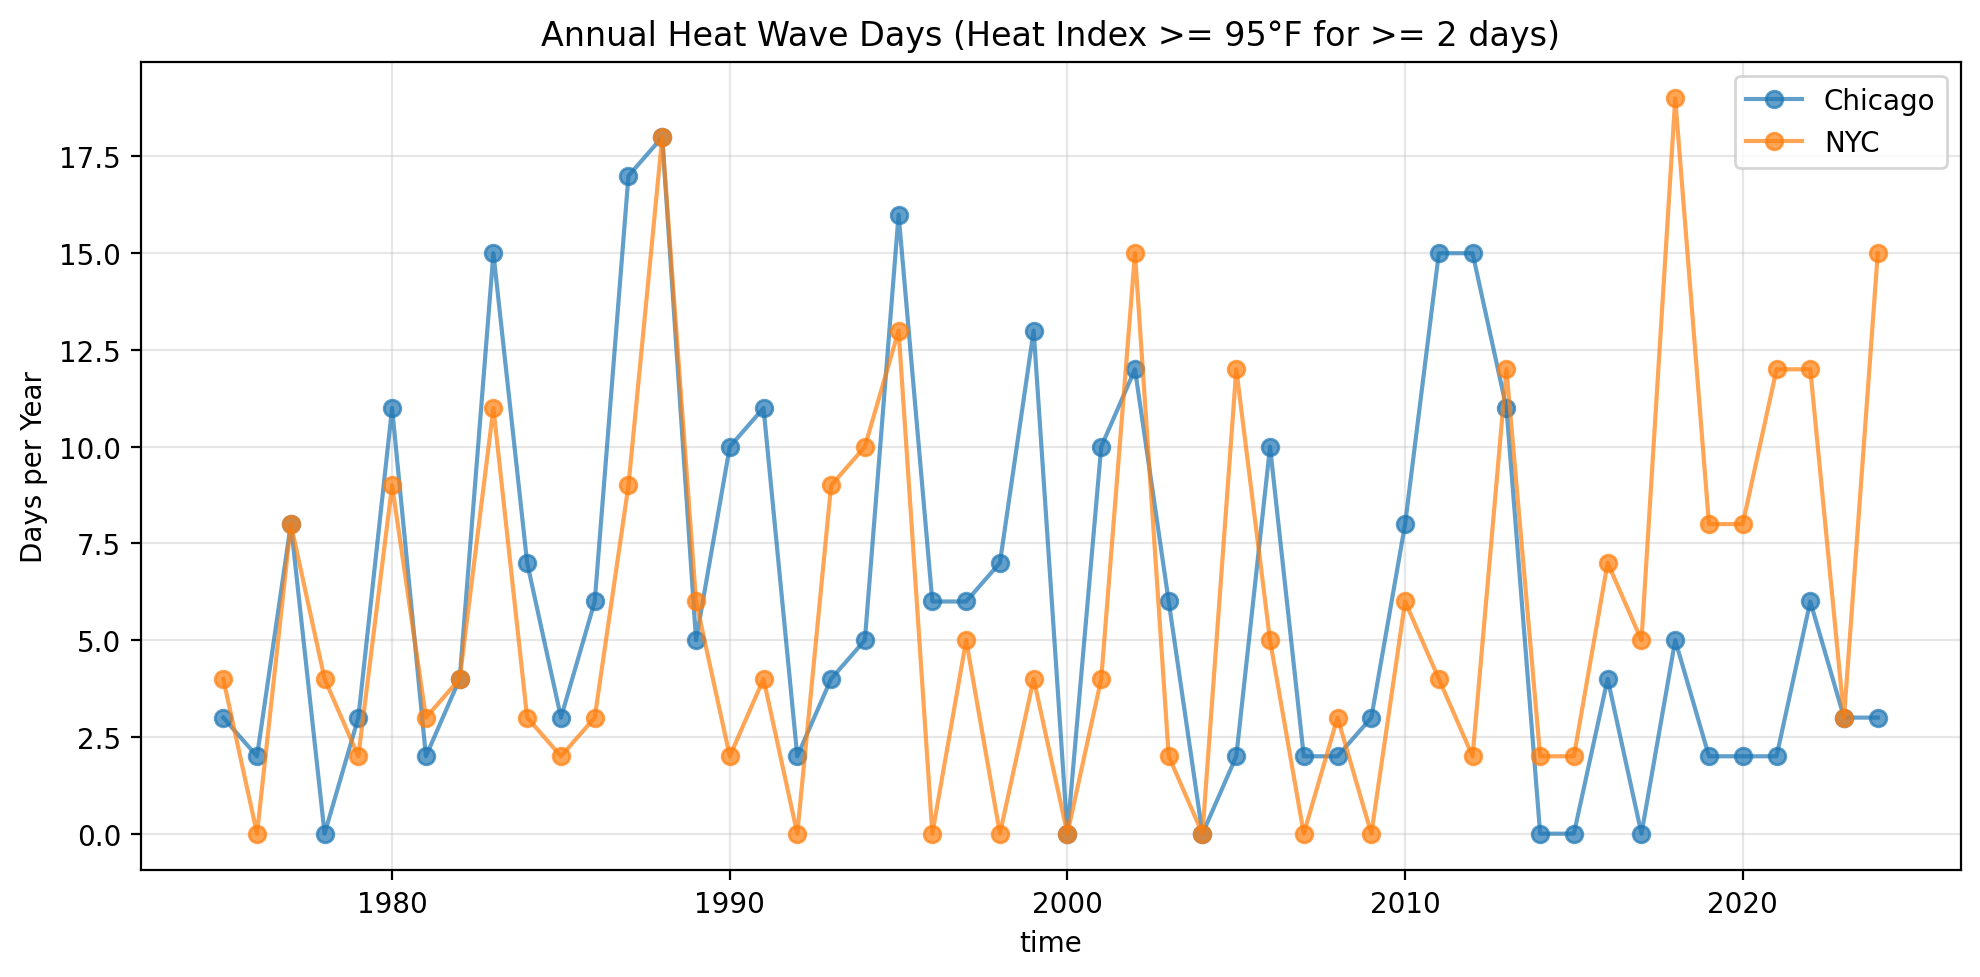

In [ ]:
# Plot Heat Waves
plt.figure(figsize=(10, 5))
chi_hw_per_year.plot(label="Chicago", marker="o", alpha=0.7)
nyc_hw_per_year.plot(label="NYC", marker="o", alpha=0.7)

plt.title("Annual Heat Wave Days (Heat Index >= 95°F for >= 2 days)")
plt.ylabel("Days per Year")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.gca()

For heat waves, we see pretty similar patterns in Chicago vs. NYC. That is, until the last decade where we see significant NYC heatwaves that aren't mirrored in Chicago.

(Gonna just put it out there, Chicago = amazing climate refuge city?!)

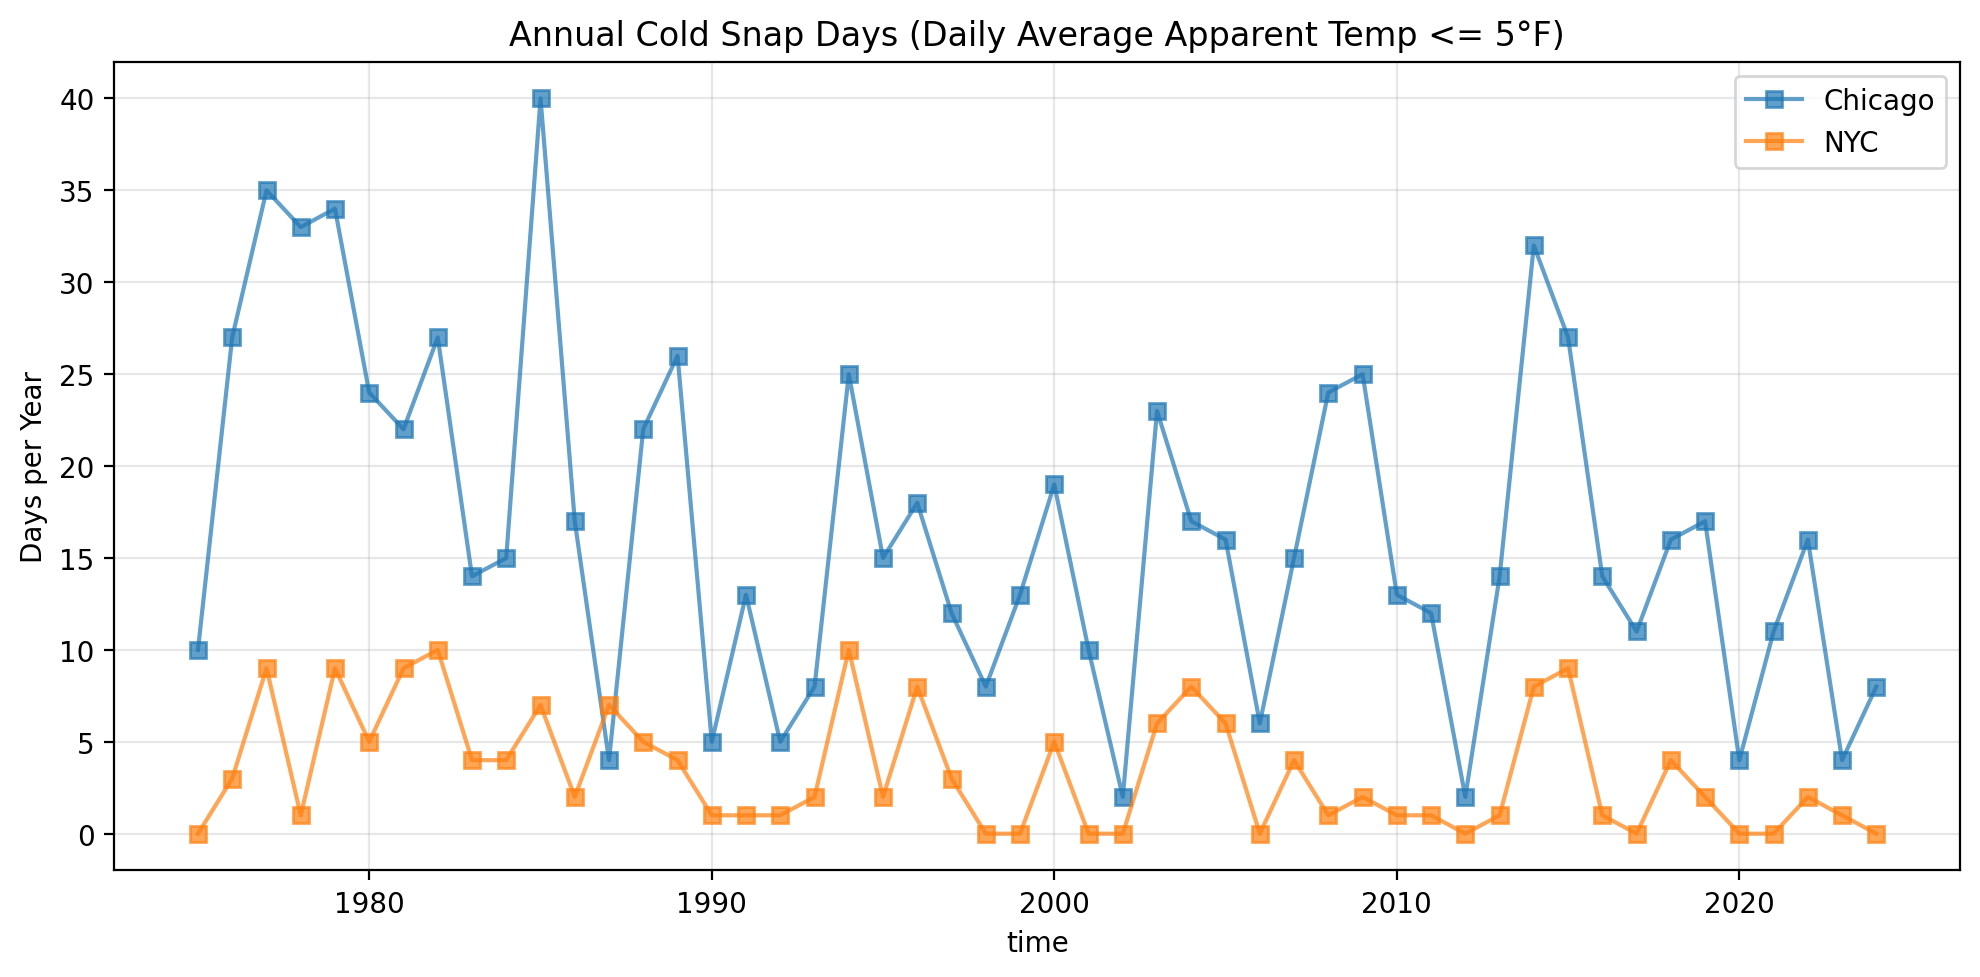

In [ ]:
# Plot Cold Snaps
plt.figure(figsize=(10, 5))
chi_cs_per_year.plot(label="Chicago", marker="s", alpha=0.7)
nyc_cs_per_year.plot(label="NYC", marker="s", alpha=0.7)

plt.title("Annual Cold Snap Days (Daily Average Apparent Temp <= 5°F)")
plt.ylabel("Days per Year")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.gca()

From the above, we can see that Chicago is the undisputed cold snap champion over NYC, with more cold snap days *almost* (1987 ruins it...) every single year in the ERA5 history.

We can also see some diabolically cold years in the Chicago history. 40 days of <= 5 degrees F **AVERAGE** temp is a bone-chilling winter.
Interestingly, that [winter of 1985](https://en.wikipedia.org/wiki/1985_North_American_cold_wave) also corresponds to the coldest day on record in Chicago, where temps hit -27 degrees F real and -60 degrees F wind chill.